<a href="https://colab.research.google.com/github/cq88661/232e-proj1/blob/main/232eproj1(2_1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**2.1(a)**

In [2]:
 #!pip install python-igraph numpy matplotlib pycairo


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 47.4 MB/s eta 0:00:00


Number of nodes: 900
Number of edges: 6139


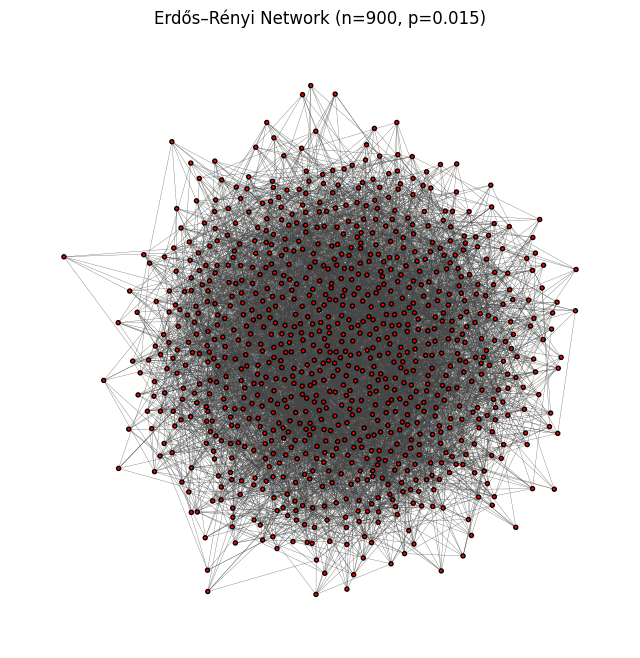

In [3]:
import igraph as ig
import matplotlib.pyplot as plt
import random

n = 900
p = 0.015

random.seed(42)

g = ig.Graph.Erdos_Renyi(
    n=n,
    p=p,
    directed=False,
    loops=False
)

print("Number of nodes:", g.vcount())
print("Number of edges:", g.ecount())

fig, ax = plt.subplots(figsize=(8, 8))

ig.plot(
    g,
    target=ax,
    vertex_size=4,
    vertex_label=None,
    edge_width=0.2
)

ax.set_title(f"Erdős–Rényi Network (n={n}, p={p})")
plt.show()

**2.1(b)**

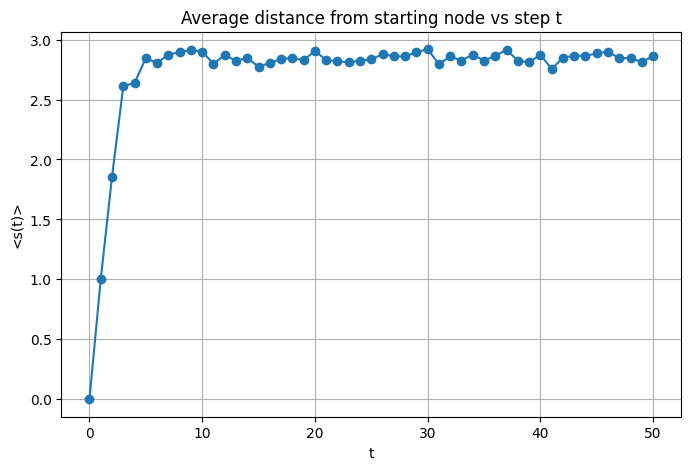

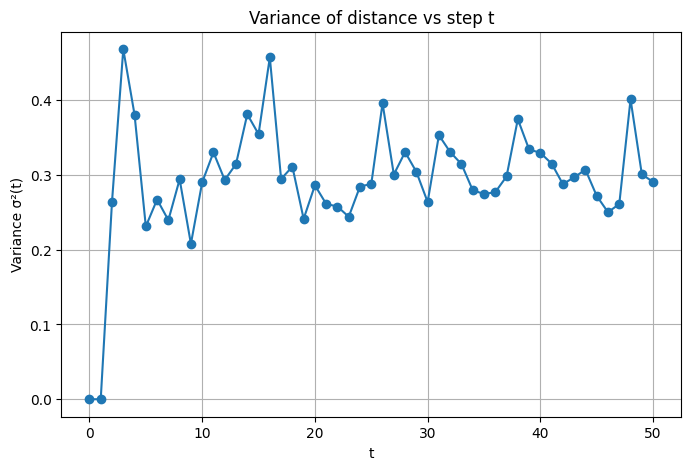

In [4]:
import igraph as ig
import numpy as np
import matplotlib.pyplot as plt
import random

n = 900
p = 0.015
random.seed(42)
np.random.seed(42)

g = ig.Graph.Erdos_Renyi(
    n=n,
    p=p,
    directed=False,
    loops=False
)

if not g.is_connected():
    g = g.components().giant()

max_steps = 50
num_trials = 200

distances_over_time = np.zeros((num_trials, max_steps + 1))

nodes = list(range(g.vcount()))

for trial in range(num_trials):
    start = random.choice(nodes)
    current = start

    distances_over_time[trial, 0] = 0

    for t in range(1, max_steps + 1):
        neighbors = g.neighbors(current)
        current = random.choice(neighbors)

        dist = g.distances(source=start, target=current)[0][0]
        distances_over_time[trial, t] = dist

mean_distance = distances_over_time.mean(axis=0)
variance_distance = distances_over_time.var(axis=0)

# Mean distance
plt.figure(figsize=(8, 5))
plt.plot(range(max_steps + 1), mean_distance, marker='o')
plt.xlabel("t")
plt.ylabel("<s(t)>")
plt.title("Average distance from starting node vs step t")
plt.grid(True)
plt.show()

# Variance
plt.figure(figsize=(8, 5))
plt.plot(range(max_steps + 1), variance_distance, marker='o')
plt.xlabel("t")
plt.ylabel("Variance σ²(t)")
plt.title("Variance of distance vs step t")
plt.grid(True)
plt.show()

**2.1(c)**

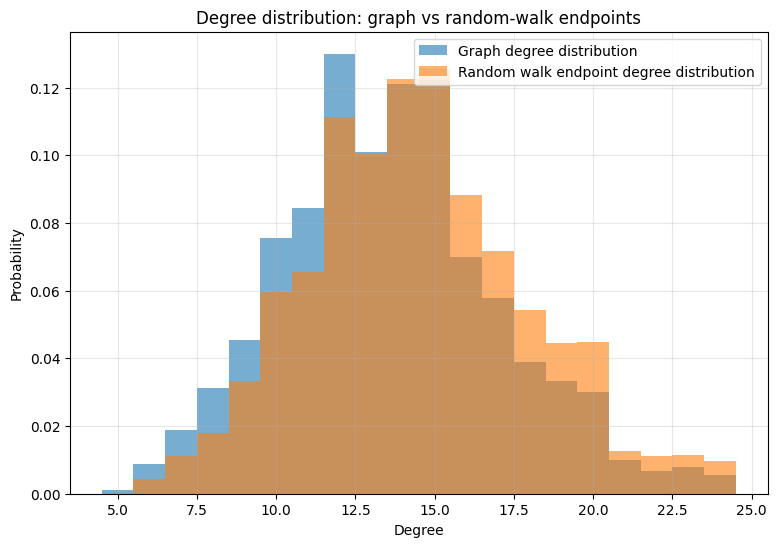

Mean degree of all nodes in graph: 13.642222222222221
Mean degree of random-walk endpoints: 14.4556


In [5]:
import igraph as ig
import numpy as np
import matplotlib.pyplot as plt
import random

n = 900
p = 0.015
random.seed(42)
np.random.seed(42)

g = ig.Graph.Erdos_Renyi(
    n=n,
    p=p,
    directed=False,
    loops=False
)

if not g.is_connected():
    g = g.components().giant()

walk_length = 100
num_trials = 5000

nodes = list(range(g.vcount()))

graph_degrees = np.array(g.degree())

endpoint_degrees = []

for _ in range(num_trials):
    start = random.choice(nodes)
    current = start

    for _ in range(walk_length):
        neighbors = g.neighbors(current)
        current = random.choice(neighbors)

    endpoint_degrees.append(g.degree(current))

endpoint_degrees = np.array(endpoint_degrees)

bins = np.arange(
    min(graph_degrees.min(), endpoint_degrees.min()),
    max(graph_degrees.max(), endpoint_degrees.max()) + 2
) - 0.5

plt.figure(figsize=(9, 6))
plt.hist(
    graph_degrees,
    bins=bins,
    density=True,
    alpha=0.6,
    label="Graph degree distribution"
)

plt.hist(
    endpoint_degrees,
    bins=bins,
    density=True,
    alpha=0.6,
    label="Random walk endpoint degree distribution"
)

plt.xlabel("Degree")
plt.ylabel("Probability")
plt.title("Degree distribution: graph vs random-walk endpoints")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("Mean degree of all nodes in graph:", graph_degrees.mean())
print("Mean degree of random-walk endpoints:", endpoint_degrees.mean())

The degree distribution of the nodes reached at the end of the random walk is slightly shifted toward larger degree values compared with the degree distribution of the whole graph.The reason is that in an undirected graph, the stationary probability of a random walk being at node i is proportional to its degree. Therefore, high-degree nodes are more likely to be visited and also more likely to be the endpoint of the walk.


**2.1(d)**

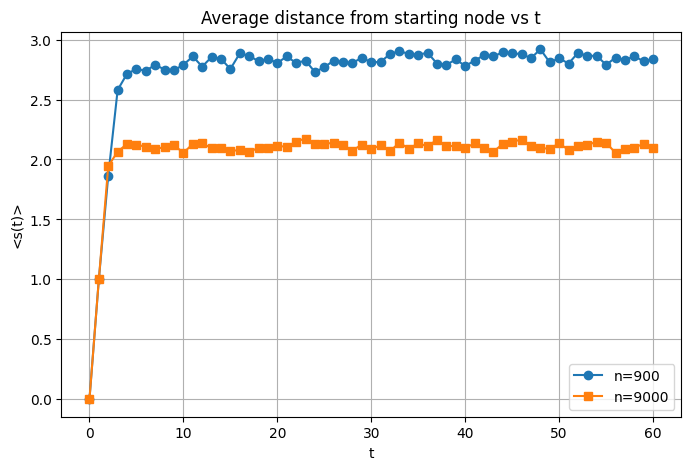

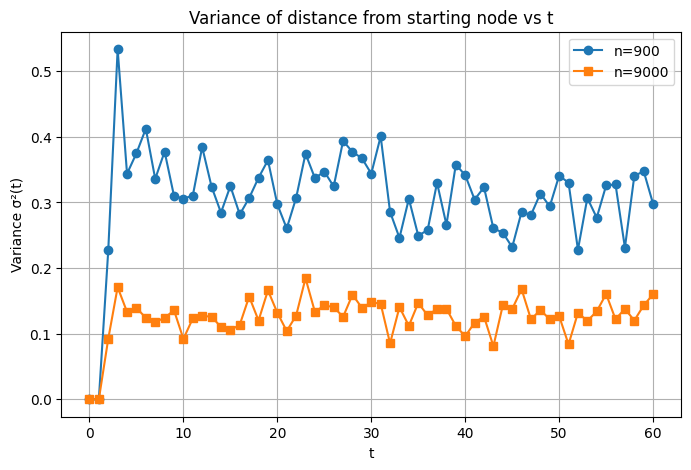

n=900:
  nodes in graph/GCC: 900
  edges: 6139
  diameter: 4
  avg shortest path length: 2.864397478680015

n=9000:
  nodes in graph/GCC: 9000
  edges: 607381
  diameter: 3
  avg shortest path length: 2.1150503389265474


In [6]:
import igraph as ig
import numpy as np
import matplotlib.pyplot as plt
import random

def random_walk_distance_stats(n, p, max_steps=60, num_trials=200, seed=42):
    random.seed(seed)
    np.random.seed(seed)

    g = ig.Graph.Erdos_Renyi(
        n=n,
        p=p,
        directed=False,
        loops=False
    )

    if not g.is_connected():
        g = g.components().giant()

    nodes = list(range(g.vcount()))
    distances_over_time = np.zeros((num_trials, max_steps + 1))

    for trial in range(num_trials):
        start = random.choice(nodes)
        current = start
        distances_over_time[trial, 0] = 0

        for t in range(1, max_steps + 1):
            neighbors = g.neighbors(current)
            current = random.choice(neighbors)

            dist = g.distances(source=start, target=current)[0][0]
            distances_over_time[trial, t] = dist

    mean_distance = distances_over_time.mean(axis=0)
    variance_distance = distances_over_time.var(axis=0)

    return g, mean_distance, variance_distance


p = 0.015
max_steps = 60
num_trials = 200

g_900, mean_900, var_900 = random_walk_distance_stats(
    n=900, p=p, max_steps=max_steps, num_trials=num_trials, seed=42
)

g_9000, mean_9000, var_9000 = random_walk_distance_stats(
    n=9000, p=p, max_steps=max_steps, num_trials=num_trials, seed=123
)

# Mean distance
plt.figure(figsize=(8, 5))
plt.plot(range(max_steps + 1), mean_900, marker='o', label='n=900')
plt.plot(range(max_steps + 1), mean_9000, marker='s', label='n=9000')
plt.xlabel("t")
plt.ylabel("<s(t)>")
plt.title("Average distance from starting node vs t")
plt.legend()
plt.grid(True)
plt.show()

# Variance
plt.figure(figsize=(8, 5))
plt.plot(range(max_steps + 1), var_900, marker='o', label='n=900')
plt.plot(range(max_steps + 1), var_9000, marker='s', label='n=9000')
plt.xlabel("t")
plt.ylabel("Variance σ²(t)")
plt.title("Variance of distance from starting node vs t")
plt.legend()
plt.grid(True)
plt.show()

print("n=900:")
print("  nodes in graph/GCC:", g_900.vcount())
print("  edges:", g_900.ecount())
print("  diameter:", g_900.diameter())
print("  avg shortest path length:", g_900.average_path_length())

print("\nn=9000:")
print("  nodes in graph/GCC:", g_9000.vcount())
print("  edges:", g_9000.ecount())
print("  diameter:", g_9000.diameter())
print("  avg shortest path length:", g_9000.average_path_length())

For the undirected random network with 9000 nodes, both $\langle s(t)\rangle$ and $\sigma^2(t)$ increase quickly at the beginning and then become stable. Compared with the n=900 case, the distance stabilizes just as fast and remains relatively small.

This is because the larger network is still highly connected and has a smaller average shortest path length and diameter than the n=900 network . Therefore, the random walker can reach most nodes within only a few steps.

The diameter plays an important role. A smaller diameter means the walker cannot get much farther from the starting node, so both the mean distance and variance saturate more quickly.